In [ ]:
from anomalib.engine import Engine
from anomalib.models import Fastflow, Padim, EfficientAd, Fre

from anomalib.metrics.evaluator import Evaluator
from anomalib.metrics import AUROC, F1Score
from anomalib.loggers import AnomalibMLFlowLogger

import torch
from pathlib import Path

import mlflow
import mlflow.pytorch
import os

os.environ["MLFLOW_ENABLE_SYSTEM_METRICS_LOGGING"] = "true"
mlflow.pytorch.autolog(log_models=True, log_every_n_epoch=1, silent=True)

In [ ]:
from dataset import CustomDataset
from dataset import CustomDataModule

train_ds = CustomDataset(root="./datasets/robotV2", split="train")
test_ds  = CustomDataset(root="./datasets/robotV2", split="test")

datamodule = CustomDataModule(root="./datasets/robotV2", train_batch_size=1, eval_batch_size=32)
datamodule.setup()

train_dataloader, test_dataloader, val_dataloader = CustomDataset.get_dataloaders(train_ds, test_ds)

In [ ]:

padim = Padim.load_from_checkpoint("./results/Padim/CustomDataModule/v9/weights/lightning/model.ckpt")
fastflow = Fastflow.load_from_checkpoint("./results/FastFlow/v2/weights/lightning/model.ckpt", weights_only=False)
efficientAD = EfficientAd.load_from_checkpoint("./results/EfficientAD/CustomDataModule/v4/weights/lightning/model.ckpt", weights_only= False)
fre = Fre.load_from_checkpoint("./results/Fre/CustomDataModule/v1/weights/lightning/model.ckpt", weights_only=False)

evaluator = Evaluator(
    val_metrics=[
        AUROC(fields=["pred_score", "gt_label"]),
        ],
    
    test_metrics=[
        AUROC(fields=["pred_score", "gt_label"]),
        F1Score(fields=["pred_label", "gt_label"]),
    ]
)


mlflow_logger = AnomalibMLFlowLogger(
    experiment_name= "Anomaly Detection",
    run_name= "EfficientAD",
    log_model= "all",
    save_dir="./mlruns"
)

#padim = Padim(
#    backbone="resnet18",
#    layers=["layer1", "layer2", "layer3"],
#    n_features=100,
#    
#)




engine = Engine(
    accelerator="gpu",
    max_epochs= 20,
    #logger= mlflow_logger,

    
)


In [ ]:
from lstm import LSTM, SequenceDataset, train_lstm

In [ ]:
engine.test(model=efficientAD, datamodule=datamodule)

In [17]:
# Engine prediction step (new cell at index 7)
predictions = engine.predict(
    dataloaders = test_dataloader,
    model = efficientAD
)

INFO:pytorch_lightning.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

c:\Users\samuc\Desktop\TFG\PythonTFG\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\samuc\Desktop\TFG\PythonTFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


In [18]:
items = [item for batch in predictions for item in batch]

scores       = torch.tensor([item.pred_score.item() for item in items])
pred_labels  = torch.tensor([item.pred_label.item() for item in items], dtype=torch.int)
gt_labels    = torch.tensor([item.gt_label.item()   for item in items], dtype=torch.int)

print(f"Total items : {len(items)}")
print(f"Anomalies   : {gt_labels.sum().item()} / {len(gt_labels)}")
print(f"Score range : [{scores.min():.4f}, {scores.max():.4f}]")

Total items : 851
Anomalies   : 710 / 851
Score range : [0.4822, 1.0000]


Image Visualization

In [ ]:
from anomalib.visualization.image import visualize_image_item

def process_batch(batch_items):
    visualizations = []
    for item in batch_items:
        vis = visualize_image_item(
            item,
            fields=["image", "anomaly_map"],
            fields_config={"anomaly_map": {"normalize": True}}
        )
        score = item.pred_score.item()
        label = item.pred_label.item()
        visualizations.append({
            "vis":   vis,
            "score": score,
            "label": label,
            "path":  item.image_path,
        })
    return visualizations

def process_predictions(predictions):
    visualizations = []
    for batches in predictions:
        visualizations.extend(process_batch(batches))
    return visualizations

def save_predictions(visualizations, output_dir="./results/test"):
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    for v in visualizations:
        name = Path(v["path"]).stem
        v["vis"].save(f"{output_dir}/{name}.png")
        

In [ ]:
SEQ_LEN    = 10
EPOCHS     = 200
LR         = 1e-4
BATCH_SIZE = 32
VAL_SPLIT  = 0.2

In [ ]:
lstm_model, history = train_lstm(
    predictions,
    seq_len     = SEQ_LEN,
    epochs      = EPOCHS,
    lr          = LR,
    batch_size  = BATCH_SIZE,
    val_split   = VAL_SPLIT,
    hidden_size = 32,
    num_layers  = 1,
    dropout     = 0.0,
)

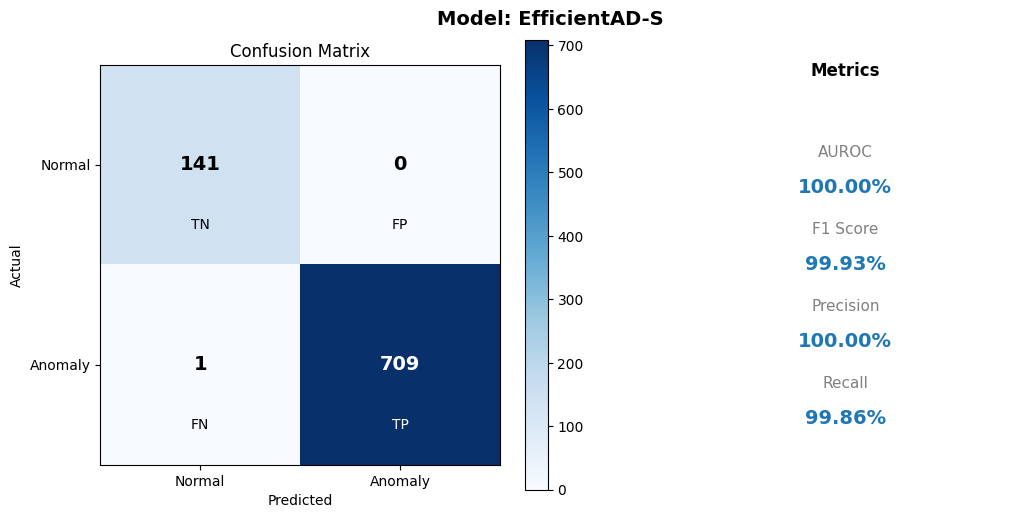

True Negatives  (TN): 141
False Positives (FP): 0
False Negatives (FN): 1
True Positives  (TP): 709


In [19]:
from plot import plot_metrics

plot_metrics("EfficientAD-S", scores, pred_labels, gt_labels)